In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from matplotlib.ticker import MaxNLocator
import bambi as bmb
import matplotlib.pylab as plt
from s0_fun_IPMs import IPM_listk, kernel_setting, IPM_listk_glmmcmc
from s0_fun_IBMs import popu_structure, IBM_1step_glm_mle, IBM_1step_gp, IBM_1step_glm
from s0_fun_base import XY_sur_compu, XY_grw_f_compu, XY_grw_nf_compu, XY_fec_compu, XY_flow_compu, XY_grw_compu
import gpflow
from tensorflow_probability import distributions as tfd
f64 = gpflow.utilities.to_default_float
import seaborn as sns
import matplotlib

In [2]:
# Loading populations
glm_mle_true_population = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_population/glm_mle_true_population.pkl", mode="rb"))
popu_whole = pickle.load(open(file = os.getcwd()+f"/true_popu/popu_whole.pkl", mode="rb")) 
# True models
glm_mle_true_models = pickle.load(open(file = os.getcwd()+f"/true_popu/glm_mle_true_models.pkl", mode="rb"))

# IPM Mesh setting
lower_p = 0
upper_p = 5
m_size_p = 50
mesh_setting = kernel_setting(m_size_p, lower_p, upper_p)
Xp = mesh_setting[0]
step_size = m_size_p // 5
ticks = [i * step_size for i in range(0, 6)]
ticks[-1] = m_size_p - 1



# IPMs for true models
true_p_glm, true_f_glm = IPM_listk(mesh_setting=mesh_setting, models=glm_mle_true_models, grw_setting='sep')

# lambdas
true_lambda_glm = np.linalg.eig(true_p_glm+true_f_glm)[0][0]
observed_lambda_glm = (np.sum(np.isnan(glm_mle_true_population["size"])) + np.sum(glm_mle_true_population["surv"] == 1)) / np.sum(np.logical_not(np.isnan(glm_mle_true_population["size"])))
 
# eigenvects
true_repro_glm = np.linalg.eig(true_p_glm.T+true_f_glm.T)[1][:,0].real/np.linalg.eig(true_p_glm.T+true_f_glm.T)[1][:,0].real[0]
true_stable_glm = np.linalg.eig(true_p_glm+true_f_glm)[1][:,0].real/np.sum(np.linalg.eig(true_p_glm+true_f_glm)[1][:,0].real)

true_stable_rep_glm = true_stable_glm * glm_mle_true_models["m_fec"].predict(pd.DataFrame(Xp, columns=['size'])).values
true_stable_rep_glm = true_stable_rep_glm/np.sum(true_stable_rep_glm)


# empi_lambda_glm = []
# np.random.seed(123456)
# z0 = popu_structure(glm_mle_true_population)
# for i in range(5000):
#     simu = IBM_1step_glm_mle(zt=z0[0], age=z0[1], models=glm_mle_true_models)
#     empi_lambda_glm.append((np.sum(np.isnan(simu["size"])) + np.sum(simu["surv"] == 1)) / np.sum(np.logical_not(np.isnan(simu["size"]))))
#     del(simu)

empi_lambda_glm = pickle.load(open(file = os.getcwd()+f"/true_popu/empi_lambda_glm.pkl", mode="rb"))

In [3]:
re_ipm = False 
truedata_style='glm'

In [4]:
if re_ipm == True:
    #setting
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'glm'

    # Loading GLM MCMCs for glm datasets
    globals()[f'trace_{truedata_style}data'] = {}
    # trace_glmdata['trace_grw'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting2+"/trace_grw.pkl", mode="rb"))
    globals()[f'trace_{truedata_style}data']['trace_grw_f'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_grw_f.pkl", mode="rb"))
    globals()[f'trace_{truedata_style}data']['trace_grw_nf'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_grw_nf.pkl", mode="rb"))
    globals()[f'trace_{truedata_style}data']['trace_fec'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_fec.pkl", mode="rb"))
    globals()[f'trace_{truedata_style}data']['trace_flow'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_flow.pkl", mode="rb"))
    globals()[f'trace_{truedata_style}data']['trace_sur'] = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/"+model_type+"/"+grw_setting+"/trace_sur.pkl", mode="rb"))

    globals()[f'model_{truedata_style}data'] = {}
    df_grw_f = XY_grw_f_compu(globals()[f'{truedata_style}_mle_true_population'])
    globals()[f'model_{truedata_style}data']['m_grw_f'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_f, axis=1))
    # grw_nf
    df_grw_nf = XY_grw_nf_compu(globals()[f'{truedata_style}_mle_true_population'])
    globals()[f'model_{truedata_style}data']['m_grw_nf'] = bmb.Model("sizeNext ~ size", pd.concat(df_grw_nf, axis=1))
    # sur
    df_sur = XY_sur_compu(globals()[f'{truedata_style}_mle_true_population'])
    globals()[f'model_{truedata_style}data']['m_sur'] = bmb.Model("sur ~ size", pd.concat(df_sur, axis=1), family='bernoulli')
    # fec
    df_fec = XY_fec_compu(globals()[f'{truedata_style}_mle_true_population'])
    globals()[f'model_{truedata_style}data']['m_fec'] = bmb.Model("fec ~ size", pd.concat(df_fec, axis=1), family='bernoulli')
    # flow
    df_flow = XY_flow_compu(globals()[f'{truedata_style}_mle_true_population'])
    globals()[f'model_{truedata_style}data']['m_flow_poi'] = bmb.Model("flow ~ size", pd.concat(df_flow, axis=1), family='poisson')
    # recru
    globals()[f'model_{truedata_style}data']['recruit_p'] = globals()[f'{truedata_style}_mle_true_models']['recruit_p']
    globals()[f'model_{truedata_style}data']['alpha'] = globals()[f'{truedata_style}_mle_true_models']['alpha']
    globals()[f'model_{truedata_style}data']['beta'] = globals()[f'{truedata_style}_mle_true_models']['beta']

    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}; stable_rep = {}
    for i in range(5000):
        c_index = np.random.randint(low=0, high=[5000, 5000, 5000, 5000, 5000], size=5)
        c_p, c_f = IPM_listk_glmmcmc(mesh_setting=mesh_setting, models=globals()[f'model_{truedata_style}data'], 
                                    traces=globals()[f'trace_{truedata_style}data'], index=c_index, grw_setting=grw_setting)
        index[i] = c_index
        diff_p[i] = c_p - globals()[f'true_p_{truedata_style}']
        diff_f[i] = c_f - globals()[f'true_f_{truedata_style}']
        eig1 = np.linalg.eig(c_p+c_f)
        eigT = np.linalg.eig(c_p.T+c_f.T) 
        growth_rate[i] = eig1[0][0]
        stable[i] = eig1[1][:,0].real/np.sum(eig1[1][:,0].real)
        repro[i] = eigT[1][:,0].real; del(eig1); del(eigT)
        stable_rep[i] = stable[i] * globals()[f'model_{truedata_style}data']["m_fec"].predict(globals()[f'trace_{truedata_style}data']["trace_fec"], 
                                                                                              data=pd.DataFrame(Xp, columns=['size']), inplace=False).posterior['fec_mean'].values[0][c_index[0], : ]
        stable_rep[i] = stable_rep[i]/np.sum(stable_rep[i])
        
    pickle.dump(index, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/index.pkl", mode="wb"))
    pickle.dump(growth_rate, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="wb"))
    pickle.dump(stable, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="wb"))
    pickle.dump(repro, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="wb"))
    pickle.dump(stable_rep, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="wb"))

else:
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'glm'

    growth_rate_glm_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="rb"))
    stable_glm_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="rb"))
    repro_glm_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="rb"))
    stable_rep_glm_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="rb"))

In [7]:
if re_ipm == True:
    #setting
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'gp'

    #Loading data
    samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
    samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
    samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
    samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
    samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))

    popu_dataset = globals()[f'{truedata_style}_mle_true_population']

    # Fec
    df_fec = XY_fec_compu(popu_dataset)  
    m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())
    m_fec_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_fec_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_fec = gpflow.optimizers.SamplingHelper(
        m_fec_new.log_posterior_density, m_fec_new.trainable_parameters
    )


    # Flow poi
    df_flow = XY_flow_compu(popu_dataset)  
    m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                    kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
    m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_flow = gpflow.optimizers.SamplingHelper(
        m_flow_poi_new.log_posterior_density, m_flow_poi_new.trainable_parameters
    )



    # Grw_f
    df_grw_f = XY_grw_f_compu(popu_dataset)    
    m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
    m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
        m_grw_f_new.log_posterior_density, m_grw_f_new.trainable_parameters
    )



    # Grw_nf
    df_grw_nf = XY_grw_nf_compu(popu_dataset)    
    m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
    m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
        m_grw_nf_new.log_posterior_density, m_grw_nf_new.trainable_parameters
    )



    # Sur
    df_sur = XY_sur_compu(popu_dataset)  
    m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

    m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
    m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
    hmc_helper_sur = gpflow.optimizers.SamplingHelper(
        m_sur_new.log_posterior_density, m_sur_new.trainable_parameters
    )


    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}; stable_rep = {}
    for i in range(5000):
        c_index = np.random.randint(low=0, high=[5000, 5000, 5000, 5000, 5000], size=5)

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new,
            "alpha": globals()[f'{truedata_style}_mle_true_models']['alpha'],
            "beta": globals()[f'{truedata_style}_mle_true_models']['beta'],
            "recruit_p": globals()[f'{truedata_style}_mle_true_models']['recruit_p']
        }


        c_p, c_f = IPM_listk(mesh_setting=mesh_setting, models=models_now, grw_setting=grw_setting)
        # index[i] = c_index
        diff_p[i] = c_p - globals()[f'true_p_{truedata_style}']
        diff_f[i] = c_f - globals()[f'true_f_{truedata_style}']
        eig1 = np.linalg.eig(c_p+c_f)
        eigT = np.linalg.eig(c_p.T+c_f.T) 
        growth_rate[i] = eig1[0][0]
        stable[i] = eig1[1][:,0].real/np.sum(eig1[1][:,0].real)
        repro[i] = eigT[1][:,0].real; del(eig1); del(eigT)
        stable_rep[i] = stable[i] * np.array(models_now["m_fec"].predict_y(Xp[:, None])[0]).reshape(-1)
        stable_rep[i] = stable_rep[i]/np.sum(stable_rep[i])
        
    pickle.dump(growth_rate, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="wb"))
    pickle.dump(stable, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="wb"))
    pickle.dump(repro, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="wb"))
    pickle.dump(stable_rep, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="wb"))

else:
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'gp'

    growth_rate_gp_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="rb"))
    stable_gp_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="rb"))
    repro_gp_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="rb"))
    stable_rep_gp_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="rb"))

In [8]:
if re_ipm == True:
    abc_index = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/p_index_6.pkl", mode="rb"))
    abc_weight = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/weight6.pkl", mode="rb"))
    #setting
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'gpabc'

    #Loading data
    samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
    samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
    samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
    samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
    samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))

    popu_dataset = globals()[f'{truedata_style}_mle_true_population']

    # Fec
    df_fec = XY_fec_compu(popu_dataset)  
    m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())
    m_fec_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_fec_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_fec = gpflow.optimizers.SamplingHelper(
        m_fec_new.log_posterior_density, m_fec_new.trainable_parameters
    )


    # Flow poi
    df_flow = XY_flow_compu(popu_dataset)  
    m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                    kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
    m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_flow = gpflow.optimizers.SamplingHelper(
        m_flow_poi_new.log_posterior_density, m_flow_poi_new.trainable_parameters
    )



    # Grw_f
    df_grw_f = XY_grw_f_compu(popu_dataset)    
    m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
    m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
        m_grw_f_new.log_posterior_density, m_grw_f_new.trainable_parameters
    )



    # Grw_nf
    df_grw_nf = XY_grw_nf_compu(popu_dataset)    
    m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
    m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
    m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
    hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
        m_grw_nf_new.log_posterior_density, m_grw_nf_new.trainable_parameters
    )



    # Sur
    df_sur = XY_sur_compu(popu_dataset)  
    m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

    m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
    m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
    hmc_helper_sur = gpflow.optimizers.SamplingHelper(
        m_sur_new.log_posterior_density, m_sur_new.trainable_parameters
    )


    np.random.seed(1234567)
    index = {}; diff_p = {}; diff_f = {}; growth_rate={}; stable = {}; repro = {}; stable_rep = {}
    for i in range(5000):
        c_index = abc_index[np.random.choice(abc_weight.shape[0], p=abc_weight)]

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new,
            "alpha": globals()[f'{truedata_style}_mle_true_models']['alpha'],
            "beta": globals()[f'{truedata_style}_mle_true_models']['beta'],
            "recruit_p": globals()[f'{truedata_style}_mle_true_models']['recruit_p']
        }


        c_p, c_f = IPM_listk(mesh_setting=mesh_setting, models=models_now, grw_setting=grw_setting)
        # index[i] = c_index
        diff_p[i] = c_p - globals()[f'true_p_{truedata_style}']
        diff_f[i] = c_f - globals()[f'true_f_{truedata_style}']
        eig1 = np.linalg.eig(c_p+c_f)
        eigT = np.linalg.eig(c_p.T+c_f.T) 
        growth_rate[i] = eig1[0][0]
        stable[i] = eig1[1][:,0].real/np.sum(eig1[1][:,0].real)
        repro[i] = eigT[1][:,0].real; del(eig1); del(eigT)
        stable_rep[i] = stable[i] * np.array(models_now["m_fec"].predict_y(Xp[:, None])[0]).reshape(-1)
        stable_rep[i] = stable_rep[i]/np.sum(stable_rep[i])
        
    pickle.dump(growth_rate, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="wb"))
    pickle.dump(stable, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="wb"))
    pickle.dump(repro, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="wb"))
    pickle.dump(stable_rep, open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="wb"))
    
else: 
    truedata_style='glm'
    grw_setting='sep'
    model_type = 'gpabc'

    growth_rate_gpabc_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/growth_rate.pkl", mode="rb"))
    stable_gpabc_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable.pkl", mode="rb"))
    repro_gpabc_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/repro.pkl", mode="rb"))
    stable_rep_gpabc_sep = pickle.load(open(file = os.getcwd()+f"/IPM_matrix/"+truedata_style+"_data/"+grw_setting+model_type+"/stable_rep.pkl", mode="rb"))

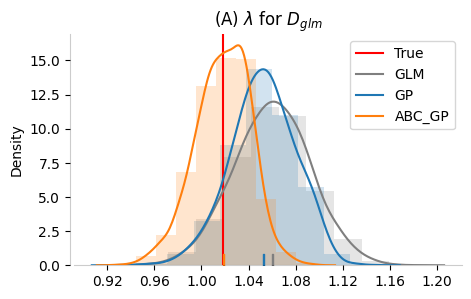

In [11]:
fig = plt.figure(figsize=(5, 3))

ax = fig.add_subplot(1, 1, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(A) $\lambda$ for $D_{glm}$')
plt.hist(np.array(list(growth_rate_glm_sep.values())).real, alpha=0.2, density=True, color='C7')
plt.hist(np.array(list(growth_rate_gp_sep.values())).real, alpha=0.2, density=True, color='C0')
plt.hist(np.array(list(growth_rate_gpabc_sep.values())).real, alpha=0.2, density=True, color='C1')
plt.axvline(true_lambda_glm.real, color='red', label='True')
sns.kdeplot(np.array(list(growth_rate_glm_sep.values())).real, color='C7', label='GLM', bw_adjust=1.3)
sns.kdeplot(np.array(list(growth_rate_gp_sep.values())).real, color='C0', label='GP', bw_adjust=1.3)
sns.kdeplot(np.array(list(growth_rate_gpabc_sep.values())).real, color='C1', label='ABC_GP', bw_adjust=1.3)
plt.plot(np.mean(np.array(list(growth_rate_glm_sep.values())).real), 0.3, marker='$|$',color='C7', markersize=10)
plt.plot(np.mean(np.array(list(growth_rate_gp_sep.values())).real), 0.3, marker='$|$',color='C0', markersize=10)
plt.plot(np.mean(np.array(list(growth_rate_gpabc_sep.values())).real), 0.3, marker='$|$',color='C1', markersize=10)

plt.legend()
# plt.savefig('plot1111.pdf')  


In [12]:
print("MSE for 'sep':")
print(f"GLM:{np.mean((np.array(list(growth_rate_glm_sep.values())).real - true_lambda_glm.real)**2)}")
print(f"GP:{np.mean((np.array(list(growth_rate_gp_sep.values())).real - true_lambda_glm.real)**2)}")
print(f"GP_abc:{np.mean((np.array(list(growth_rate_gpabc_sep.values())).real - true_lambda_glm.real)**2)}")

MSE for 'sep':
GLM:0.0027570487001843773
GP:0.001899063675151431
GP_abc:0.0005466006185604106


In [13]:
print("Bias for 'sep':")
print(f"GLM:{np.mean((np.array(list(growth_rate_glm_sep.values())).real - true_lambda_glm.real))}")
print(f"GP:{np.mean((np.array(list(growth_rate_gp_sep.values())).real - true_lambda_glm.real))}")
print(f"GP_abc:{np.mean((np.array(list(growth_rate_gpabc_sep.values())).real - true_lambda_glm.real))}")

Bias for 'sep':
GLM:0.04121704689166171
GP:0.03355984939080457
GP_abc:-0.0003289212651888466


In [17]:
kl_stable_glm_sep = []
for i in range(5000):
    kl_stable_glm_sep.append(np.sum(np.log(stable_glm_sep[i]/true_stable_glm) * stable_glm_sep[i]))

kl_stable_gp_sep = []
for i in range(5000):
    kl_stable_gp_sep.append(np.sum(np.log(stable_gp_sep[i]/true_stable_glm) * stable_gp_sep[i]))

kl_stable_gpabc_sep = []
for i in range(5000):
    kl_stable_gpabc_sep.append(np.sum(np.log(stable_gpabc_sep[i]/true_stable_glm) * stable_gpabc_sep[i]))

print("(mean) KL in stable distance for 'sep':")
print(f"GLM:{np.round(np.mean(kl_stable_glm_sep), 4)}")
print(f"GP:{np.round(np.mean(kl_stable_gp_sep), 4)}")
print(f"GP_abc:{np.round(np.mean(kl_stable_gpabc_sep), 4)}")

(mean) KL in stable distance for 'sep':
GLM:0.0104
GP:0.0079
GP_abc:0.0072


In [18]:
kl_stable_rep_glm_sep = []
for i in range(5000):
    kl_stable_rep_glm_sep.append(np.sum(np.log(stable_rep_glm_sep[i]/true_stable_rep_glm) * stable_rep_glm_sep[i]))

kl_stable_rep_gp_sep = []
for i in range(5000):
    kl_stable_rep_gp_sep.append(np.sum(np.log(stable_rep_gp_sep[i]/true_stable_rep_glm) * stable_rep_gp_sep[i]))

kl_stable_rep_gpabc_sep = []
for i in range(5000):
    kl_stable_rep_gpabc_sep.append(np.sum(np.log(stable_rep_gpabc_sep[i]/true_stable_rep_glm) * stable_rep_gpabc_sep[i]))

print("(mean) KL in stable rep for 'sep':")
print(f"GLM:{np.round(np.mean(kl_stable_rep_glm_sep), 4)}")
print(f"GP:{np.round(np.mean(kl_stable_rep_gp_sep), 4)}")
print(f"GP_abc:{np.round(np.mean(kl_stable_rep_gpabc_sep), 4)}")

(mean) KL in stable rep for 'sep':
GLM:0.0161
GP:0.0128
GP_abc:0.0119


In [19]:
def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    return dot_product / (norm_vector1 * norm_vector2)

denom = np.linalg.eig(true_p_glm.T+true_f_glm.T)[1][:,0].real[0]
cos_repro_glm_sep = []
for i in range(5000):
    cos_repro_glm_sep.append(cosine_similarity(np.abs(repro_glm_sep[i])/denom, true_repro_glm))
cos_repro_gp_sep = []
for i in range(5000):
    cos_repro_gp_sep.append(cosine_similarity(np.abs(repro_gp_sep[i])/denom, true_repro_glm))
cos_repro_gpabc_sep = []
for i in range(5000):
    cos_repro_gpabc_sep.append(cosine_similarity(np.abs(repro_gpabc_sep[i])/denom, true_repro_glm))

print("(mean) cos in reproductive values for 'sep':")
print(f"GLM:{np.round(np.mean(cos_repro_glm_sep), 4)}")
print(f"GP:{np.round(np.mean(cos_repro_gp_sep), 4)}")
print(f"GP_abc:{np.round(np.mean(cos_repro_gpabc_sep), 4)}")

(mean) cos in reproductive values for 'sep':
GLM:0.998
GP:0.9954
GP_abc:0.9953


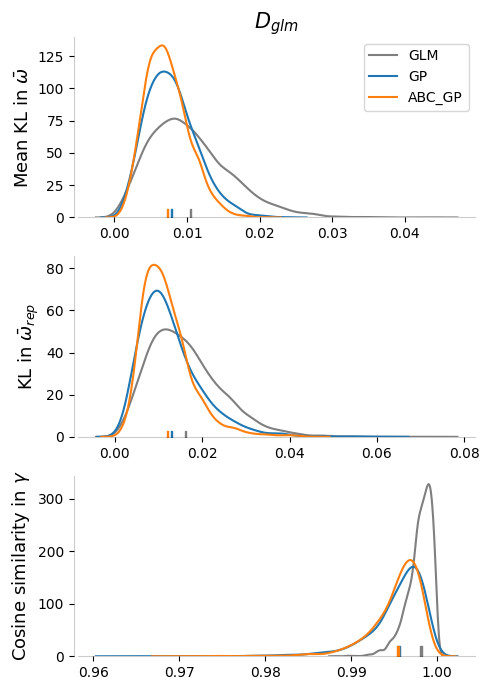

In [20]:
# Create figure and subplots
fig = plt.figure(figsize=(5, 7))

# Colors for each dataset
colors = ['C0', 'C1', 'C2']

# Violin plot for the first set of data (separated)
ax1 = fig.add_subplot(3, 1, 1)
plt.ylabel(r"Mean KL in $\bar{\omega}$",fontsize=13)
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.spines['left'].set_position(('outward', 3)); ax1.spines['left'].set_alpha(0.2); ax1.spines['bottom'].set_alpha(0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
plt.title('$D_{glm}$',fontsize=15)
sns.kdeplot(kl_stable_glm_sep, color='C7', label='GLM')
sns.kdeplot(kl_stable_gp_sep, color='C0',  label='GP', bw_adjust=1.3)
sns.kdeplot(kl_stable_gpabc_sep, color='C1',  label='ABC_GP', bw_adjust=1.3)
plt.plot(np.mean(kl_stable_glm_sep), 1, marker='$|$', color='C7', markersize=10)
plt.plot(np.mean(kl_stable_gp_sep), 1,  marker='$|$', color='C0', markersize=10)
plt.plot(np.mean(kl_stable_gpabc_sep), 1, marker='$|$', color='C1', markersize=10)

plt.xlabel('')
plt.legend()

# Violin plot for the first set of data (separated)
ax1 = fig.add_subplot(3, 1, 2)
plt.ylabel(r"KL in $\bar{\omega}_{rep}$",fontsize=13)
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.spines['left'].set_position(('outward', 3)); ax1.spines['left'].set_alpha(0.2); ax1.spines['bottom'].set_alpha(0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)


sns.kdeplot(kl_stable_rep_glm_sep, color='C7')
sns.kdeplot(kl_stable_rep_gp_sep, color='C0', bw_adjust=1.3)
sns.kdeplot(kl_stable_rep_gpabc_sep, color='C1', bw_adjust=1.3)
plt.plot(np.mean(kl_stable_rep_glm_sep), 1, marker='$|$', color='C7')
plt.plot(np.mean(kl_stable_rep_gp_sep), 1,  marker='$|$', color='C0')
plt.plot(np.mean(kl_stable_rep_gpabc_sep), 1, marker='$|$', color='C1')



# Violin plot for the first set of data (separated)
ax1 = fig.add_subplot(3, 1, 3)
plt.ylabel(r"Cosine similarity in $\gamma$",fontsize=13)
# ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.spines['left'].set_position(('outward', 3)); ax1.spines['left'].set_alpha(0.2); ax1.spines['bottom'].set_alpha(0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
sns.kdeplot(cos_repro_glm_sep, color='C7')
sns.kdeplot(cos_repro_gp_sep, color='C0', bw_adjust=1.3)
sns.kdeplot(cos_repro_gpabc_sep, color='C1', bw_adjust=1.3)
plt.plot(np.mean(cos_repro_glm_sep), 1, marker='$|$', color='C7', markersize=15)
plt.plot(np.mean(cos_repro_gp_sep), 1,  marker='$|$', color='C0', markersize=15)
plt.plot(np.mean(cos_repro_gpabc_sep), 1, marker='$|$', color='C1', markersize=15)


plt.tight_layout()
# plt.savefig('plot2222.pdf')  
plt.show()
